<a href="https://colab.research.google.com/github/ketanp23/deeplearningclass/blob/main/DL_Lab1_Neurons_and_Activations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DL Lab 1 · Neurons & Activation Functions

> **Deep Learning foundations — Lab.** Run top to bottom (Runtime → Run all). Read the notes, run the code, and finish
> the **Your turn 🧪** cell. We build from scratch with NumPy so nothing is hidden.

## What you'll build
The atom of deep learning — a single **neuron** — and the **activation functions** that give networks their power:
sigmoid, tanh, ReLU, and softmax. We'll plot each one *and its gradient*, because the gradient is what learning uses.

In [1]:
import numpy as np, matplotlib.pyplot as plt
VIOLET, CYAN, ROSE = "#6C5CE7", "#22D3EE", "#FB7185"
np.random.seed(0)

## 1 · A single neuron
$$z = \mathbf{w}\cdot\mathbf{x} + b, \qquad a = f(z)$$
Multiply inputs by weights, add a bias, squash with an activation.

In [2]:
def neuron(x, w, b, f):
    z = np.dot(w, x) + b      # weighted sum
    return f(z), z

sigmoid = lambda z: 1/(1+np.exp(-z))
out, z = neuron(x=np.array([0.5, -0.4]), w=np.array([1.0, -1.0]), b=0.2, f=sigmoid)
print(f"weighted sum z = {z:.3f}   ->   activation a = {out:.3f}")

weighted sum z = 1.100   ->   activation a = 0.750


## 2 · The activation zoo + their gradients

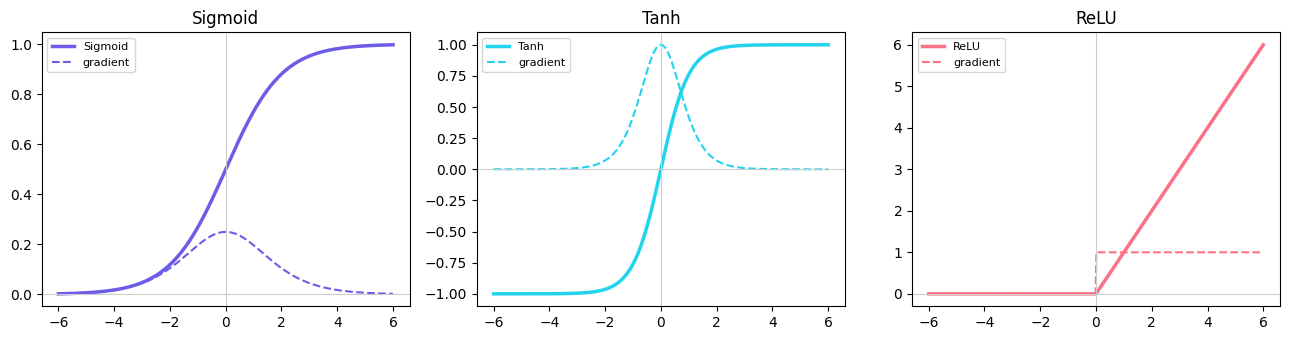

Notice: sigmoid/tanh gradients vanish at the edges (saturation); ReLU's gradient is a clean 0 or 1.


In [3]:
def sigmoid(z):   return 1/(1+np.exp(-z))
def d_sigmoid(z): s=sigmoid(z); return s*(1-s)
def tanh(z):      return np.tanh(z)
def d_tanh(z):    return 1-np.tanh(z)**2
def relu(z):      return np.maximum(0, z)
def d_relu(z):    return (z>0).astype(float)

z = np.linspace(-6, 6, 400)
fig, ax = plt.subplots(1, 3, figsize=(13,3.5))
for a,(name,f,df,c) in zip(ax, [("Sigmoid",sigmoid,d_sigmoid,VIOLET),
                                ("Tanh",tanh,d_tanh,CYAN),
                                ("ReLU",relu,d_relu,ROSE)]):
    a.plot(z, f(z), color=c, lw=2.5, label=f"{name}")
    a.plot(z, df(z), color=c, lw=1.5, ls="--", label="gradient")
    a.axhline(0,color="#ccc",lw=.8); a.axvline(0,color="#ccc",lw=.8)
    a.set_title(name); a.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Notice: sigmoid/tanh gradients vanish at the edges (saturation); ReLU's gradient is a clean 0 or 1.")

## 3 · Softmax — turning scores into probabilities
$$\text{softmax}(z)_i = \frac{e^{z_i}}{\sum_j e^{z_j}}$$
Used at the output of a classifier. Note the numerically-stable version subtracts the max.

scores      : [2.  1.  0.1]
probabilities: [0.659 0.242 0.099]  sum = 1.0


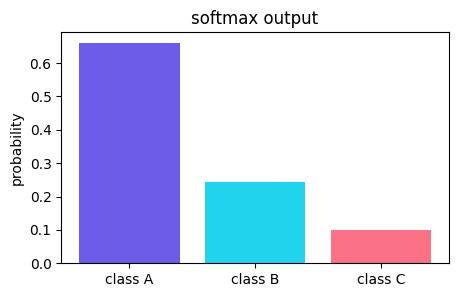

In [4]:
def softmax(z):
    z = z - np.max(z)          # numerical stability
    e = np.exp(z)
    return e / e.sum()

scores = np.array([2.0, 1.0, 0.1])
p = softmax(scores)
print("scores      :", scores)
print("probabilities:", np.round(p, 3), " sum =", round(p.sum(), 3))

plt.figure(figsize=(5,3))
plt.bar(["class A","class B","class C"], p, color=[VIOLET,CYAN,ROSE])
plt.title("softmax output"); plt.ylabel("probability"); plt.show()

## 4 · Why non-linearity matters
Stack two **linear** neurons and you still only get a line. The activation is what lets a network bend.

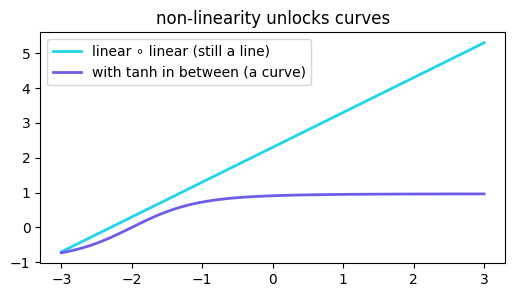

In [5]:
x = np.linspace(-3,3,100)
lin = 2*(0.5*x + 1) + 0.3            # linear-of-linear = still linear
nonlin = np.tanh(2*np.tanh(0.5*x+1)) # activation in between = a curve
plt.figure(figsize=(6,3))
plt.plot(x, lin, color=CYAN, lw=2, label="linear ∘ linear (still a line)")
plt.plot(x, nonlin, color=VIOLET, lw=2, label="with tanh in between (a curve)")
plt.legend(); plt.title("non-linearity unlocks curves"); plt.show()

## Your turn 🧪
1. Add **Leaky ReLU** (`max(0.1*z, z)`) and its gradient to the plot. Why does it fix "dead" neurons?
2. Feed softmax two nearly-equal scores, then make one much larger — watch the winner take almost all the probability.
3. Build a 2-input neuron and find weights/bias that implement a logical **AND** gate (output ≈1 only when both inputs are 1).

In [6]:
# Your turn: an AND gate with one neuron
w, b = np.array([6.0, 6.0]), -9.0
for x in [[0,0],[0,1],[1,0],[1,1]]:
    print(x, "->", round(float(sigmoid(np.dot(w, x)+b)), 2))

[0, 0] -> 0.0
[0, 1] -> 0.05
[1, 0] -> 0.05
[1, 1] -> 0.95
